In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:


file = "20260907 calibration on site Accra.xlsx"

df = pd.read_excel(file)

x = df["raw scale"].to_numpy()
y = df["weight"].to_numpy()

# Linear fit: weight = a * raw_scale + b
fit, cov = np.polyfit(x, y, 1, cov=True)
a, b = fit
a_err, b_err = np.sqrt(np.diag(cov))

y_fit = a * x + b
r2 = 1 - np.sum((y - y_fit)**2) / np.sum((y - np.mean(y))**2)

print(f"Calibration: weight = ({a:.6e} ± {a_err:.1e}) * raw_scale + ({b:.3f} ± {b_err:.3f})")
print(f"R² = {r2:.5f}")



Calibration: weight = (-3.660783e-05 ± 6.6e-07) * raw_scale + (6.093 ± 0.183)
R² = 0.99803


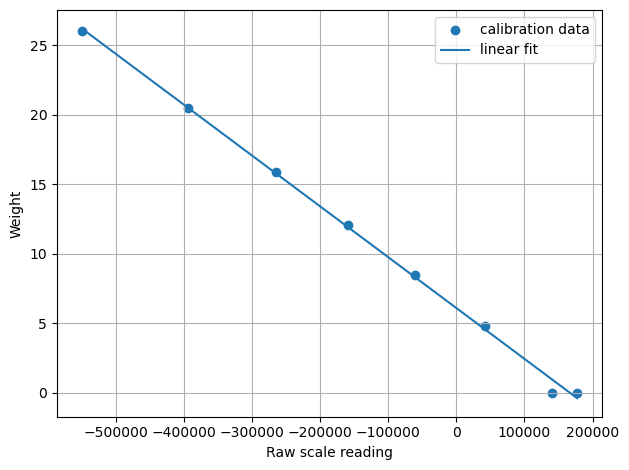

In [4]:
plt.scatter(x, y, label="calibration data")

x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, a * x_line + b, label="linear fit")

plt.xlabel("Raw scale reading")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()